In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from DataCollapse import *
from src.fss.data_collapse import *


# Generate pseudo data

In [4]:
def generate_pseudo_data(pc=0.5,p_list=np.round(np.linspace(0.45,.55,11),2),nu=1,L_list=np.arange(10,20,2),beta=0.5, f=lambda x: (1-x)**(1/2),seed=0, epsilon=0.01,N=100):
    """Generate pseudo data following y~L^{-beta/nu} f[(p-p_c)L^{1/nu}] + epsilon, where epsilon is a random noise, N is the sample size"""
    rng=np.random.default_rng(seed)
    data_dict={(p,L): L**(-beta/nu)*f((p-pc)* L **(1/nu))+ rng.normal(0,epsilon,N) for L in L_list for p in p_list}
    index = pd.MultiIndex.from_tuples([key for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': data_dict.values()}, index=index)
    return df
    

In [5]:
# Generate psudo data with p_c=0.5, nu=1, beta=0.5
df=generate_pseudo_data(pc=0.5,nu=1,beta=0.5)

In [8]:
df.head()

,,observations
p,L,
0.45,10,"[0.3885556368316756, 0.38597728598782866, 0.39..."
0.46,10,"[0.3791925671761428, 0.3840628690102522, 0.372..."
0.47,10,"[0.35391977556335846, 0.35442094906025867, 0.3..."
0.48,10,"[0.3584427510549405, 0.35278089387003736, 0.35..."
0.49,10,"[0.328058077325631, 0.3374978203093675, 0.3172..."


In [40]:
df['estimator']=df['observations'].apply(np.mean)
df['standard_error']=df['observations'].apply(lambda x: np.std(x)/np.sqrt(len(x)))
df[['estimator','standard_error']].head()

,,estimator,standard_error
p,L,,
0.45,10,0.388109,0.000962
0.46,10,0.373660,0.000956
0.47,10,0.359175,0.001116
0.48,10,0.346020,0.000924
0.49,10,0.331783,0.001084


## Load data

In [32]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

## Plot the raw data

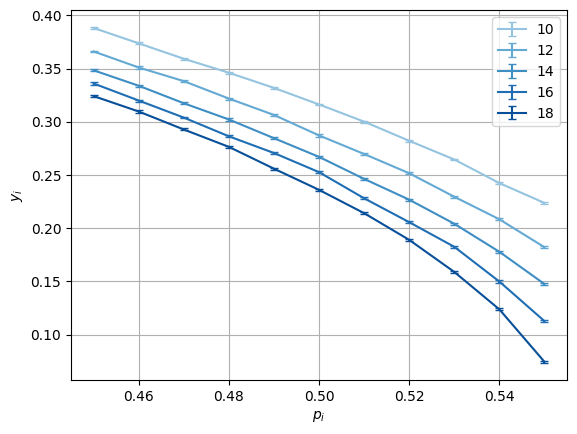

In [33]:
dc.plot_data_collapse(raw=True, errorbar=True)

## Finite size scaling

In [34]:
dc.datacollapse(p_c=0.505,nu=1.3,beta=0.0,p_c_vary=True,beta_vary=True,nu_vary=True)

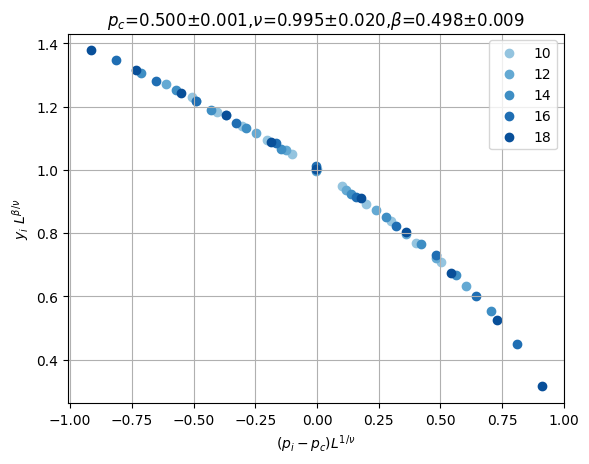

In [35]:
dc.plot_data_collapse()

## Load data with `estimator='manual'` 

In [41]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],estimator='manual',)

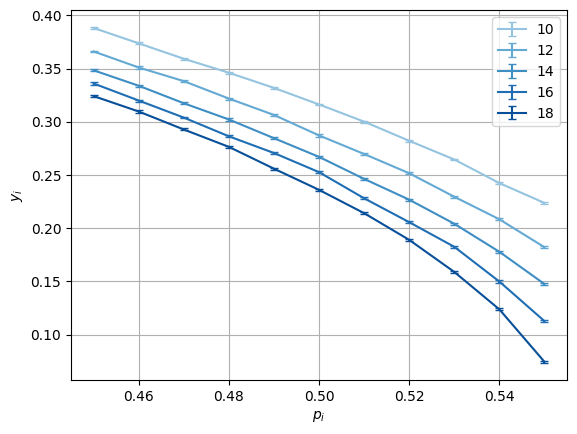

In [42]:
dc.plot_data_collapse(raw=True, errorbar=True)

# Generate data with drifting

In [3]:
import numpy as np, pandas as pd

# Generate dummy data with known parameters
# O = a00 + a10*x + (a01 + a11*x)*L^{-y}
# where x = (p - p_c) * L^{1/nu}
p_c_true, nu_true, y_true = 0.5, 1.3, 1.0
a_true = np.array([[1.0, 0.5],    # a00, a01
                   [0.3, 0.2]])   # a10, a11 (n1=1, linear)

rng = np.random.default_rng(0)
p_list = np.round(np.linspace(0.45, 0.55, 11), 2)
L_list = np.array([8, 16, 32, 64])  # wide range so L^{-y} varies 8x

data = {}
for L in L_list:
    for p in p_list:
        x = (p - p_c_true) * L ** (1 / nu_true)
        ir = L ** (-y_true)
        y_mean = sum(a_true[j1, j2] * x**j1 * ir**j2
                     for j1 in range(2) for j2 in range(2))
        data[(p, L)] = rng.normal(y_mean, 0.01, 100)

index = pd.MultiIndex.from_tuples(list(data.keys()), names=['p', 'L'])
df = pd.DataFrame({'observations': list(data.values())}, index=index)


In [4]:
dc=DataCollapse(df, p_='p',L_='L',params={},p_range=[0.45,0.55],)

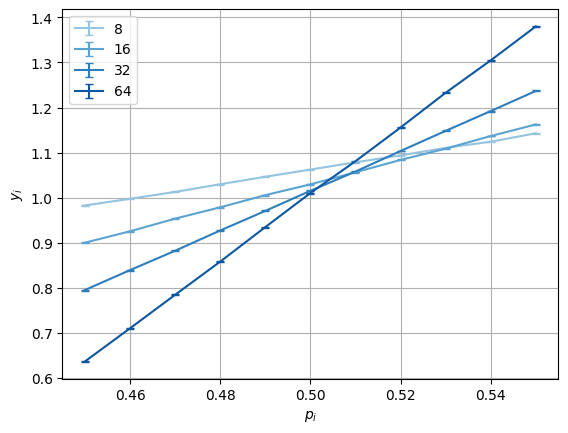

In [5]:
dc.plot_data_collapse(raw=True, errorbar=True)

## Verify with (n1, n2) = (2, 1)

In [6]:
# Fit with corrections (n1=1, n2=1 matches the true model)
dc = DataCollapse(df, p_='p', L_='L', params={}, p_range=[0.45, 0.55])
res = dc.datacollapse_with_drift_GLS(n1=1, n2=1, p_c=0.5, nu=1.0, y=1.0)
print(res.params)  # should recover p_c≈0.5, nu≈1.3, y≈1.0


Parameters([('p_c', <Parameter 'p_c', value=np.float64(0.4994771683588808) +/- 0.000519, bounds=[0:1]>), ('nu', <Parameter 'nu', value=np.float64(1.3004515579166385) +/- 0.0117, bounds=[0:2]>), ('y', <Parameter 'y', value=np.float64(0.9171365484630931) +/- 0.0972, bounds=[0:5]>), ('beta', <Parameter 'beta', value=0 (fixed), bounds=[0:2]>)])


In [7]:
res.params

name,value,standard error,relative error,initial value,min,max,vary
p_c,0.49947717,5.1872e-04,(0.10%),0.5,0.00000000,1.00000000,True
nu,1.30045156,0.01171366,(0.90%),1.0,0.00000000,2.00000000,True
y,0.91713655,0.09719945,(10.60%),1.0,0.00000000,5.00000000,True
beta,0.00000000,0.00000000,,0,0.00000000,2.00000000,False


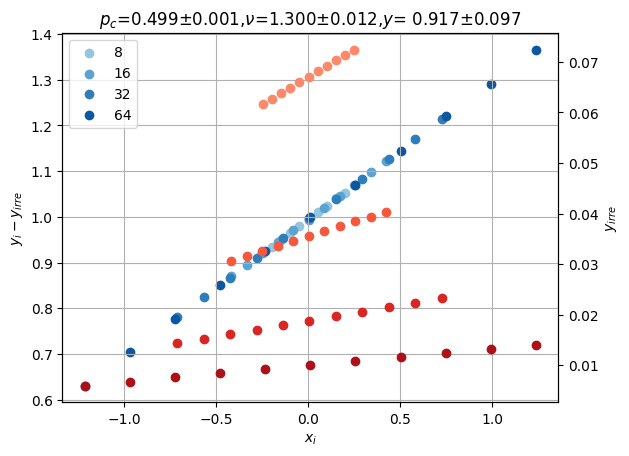

In [8]:
dc.plot_data_collapse(drift=True, driftcollapse=True)

## Model selection via grid search

100%|██████████| 9/9 [00:00<00:00, 156.43it/s]


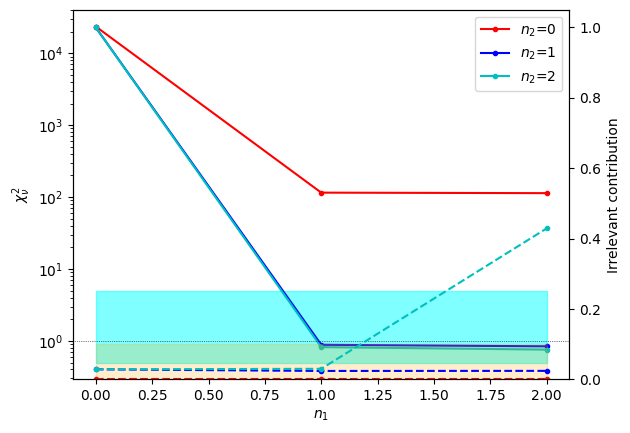

In [10]:
# Grid search for optimal (n1, n2)
model_dict = grid_search(
    n1_list=range(0, 3), n2_list=range(0, 3),
    p_c=0.5, nu=1.0, y=1.0,
    p_c_range=(0.45, 0.55), nu_range=(0.5, 2.0),
    df=df, p_='p', L_='L', params={}, p_range=[0.45, 0.55]
)
plot_chi2_ratio(model_dict)